In [1]:
from scripts.visual_degradation import add_awgn
from scripts.data_visualization import load_sample,overlay_masks,overlay_boxes
from scripts.converters import convert_boxes_to_xywh
from matplotlib import pyplot as plt

from transformers import Sam3Processor, Sam3Model
import torch
from PIL import Image
import cv2

img_name ='sa_11177073'

In [4]:
device = "cuda" if torch.cuda.is_available() else "cpu"

model = Sam3Model.from_pretrained("../models/sam3").to(device)
processor = Sam3Processor.from_pretrained("../models/sam3")
model.eval()

Loading weights:   0%|          | 0/1468 [00:00<?, ?it/s]

Sam3Model(
  (vision_encoder): Sam3VisionModel(
    (backbone): Sam3ViTModel(
      (embeddings): Sam3ViTEmbeddings(
        (patch_embeddings): Sam3ViTPatchEmbeddings(
          (projection): Conv2d(3, 1024, kernel_size=(14, 14), stride=(14, 14), bias=False)
        )
        (dropout): Dropout(p=0.0, inplace=False)
      )
      (layer_norm): LayerNorm((1024,), eps=1e-06, elementwise_affine=True)
      (layers): ModuleList(
        (0-31): 32 x Sam3ViTLayer(
          (layer_norm1): LayerNorm((1024,), eps=1e-06, elementwise_affine=True)
          (rotary_emb): Sam3ViTRotaryEmbedding()
          (attention): Sam3ViTRoPEAttention(
            (q_proj): Linear(in_features=1024, out_features=1024, bias=True)
            (k_proj): Linear(in_features=1024, out_features=1024, bias=True)
            (v_proj): Linear(in_features=1024, out_features=1024, bias=True)
            (o_proj): Linear(in_features=1024, out_features=1024, bias=True)
          )
          (layer_norm2): LayerNorm((1024,

In [24]:
def run_sam3(img):
    inputs = processor(images=Image.fromarray(img), text="object", return_tensors="pt").to(device)
    
    with torch.no_grad():
        outputs = model(**inputs)
    
    results = processor.post_process_instance_segmentation(
        outputs,
        threshold=0.1,
        target_sizes=inputs.get("original_sizes").tolist()
    )[0]
    
    return results

In [ ]:
img, _ = load_sample(img_name)
noisy_img_1 = add_awgn(img, sigma=10)
noisy_img_2 = add_awgn(img, sigma=25)
noisy_img_3 = add_awgn(img, sigma=50)


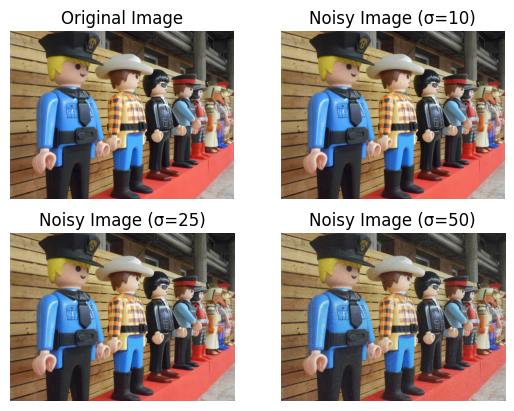

In [ ]:
fig, axs = plt.subplots(2, 2)
axs[0, 0].imshow(img)
axs[0, 0].set_title('Original Image')
axs[0, 0].axis('off')
axs[0, 1].imshow(noisy_img_1)
axs[0, 1].set_title('Noisy Image (σ=10)')
axs[0, 1].axis('off')
axs[1, 0].imshow(noisy_img_2)
axs[1, 0].set_title('Noisy Image (σ=25)')
axs[1, 0].axis('off')
axs[1, 1].imshow(noisy_img_3)
axs[1, 1].set_title('Noisy Image (σ=50)')
axs[1, 1].axis('off')
plt.show()

In [33]:
results = run_sam3(img)

masks = results["masks"]
boxes = convert_boxes_to_xywh(results["boxes"].cpu().numpy())

img = overlay_masks(img, masks)
img = overlay_boxes(img, boxes, color=(255, 0, 0), label="predicted")

print(len(results["masks"]))

10


In [34]:
results = run_sam3(noisy_img_1)

masks = results["masks"]
boxes = convert_boxes_to_xywh(results["boxes"].cpu().numpy())

noisy_img_1 = overlay_masks(noisy_img_1, masks)
noisy_img_1 = overlay_boxes(noisy_img_1, boxes, color=(255, 0, 0), label="predicted")
print(len(results["masks"]))

12


In [35]:
results = run_sam3(noisy_img_2)

masks = results["masks"]
boxes = convert_boxes_to_xywh(results["boxes"].cpu().numpy())

noisy_img_2 = overlay_masks(noisy_img_2, masks)
noisy_img_2 = overlay_boxes(noisy_img_2, boxes, color=(255, 0, 0), label="predicted")
print(len(results["masks"]))

10


In [36]:
results = run_sam3(noisy_img_3)

masks = results["masks"]
boxes = convert_boxes_to_xywh(results["boxes"].cpu().numpy())

noisy_img_3 = overlay_masks(noisy_img_3, masks)
noisy_img_3 = overlay_boxes(noisy_img_3, boxes, color=(255, 0, 0), label="predicted")
print(len(results["masks"]))

10


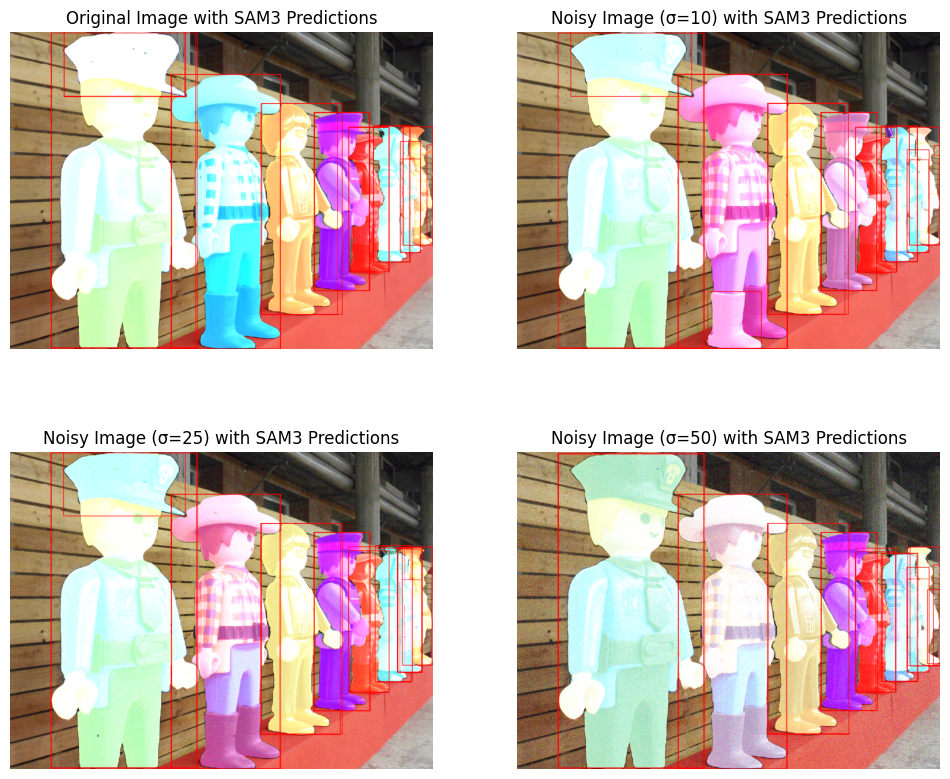

In [37]:
plt.figure(figsize=(12, 10))
plt.subplot(2, 2, 1)
plt.imshow(img)
plt.title('Original Image with SAM3 Predictions')
plt.axis('off')
plt.subplot(2, 2, 2)
plt.imshow(noisy_img_1)
plt.title('Noisy Image (σ=10) with SAM3 Predictions')
plt.axis('off')
plt.subplot(2, 2, 3)
plt.imshow(noisy_img_2)
plt.title('Noisy Image (σ=25) with SAM3 Predictions')
plt.axis('off')
plt.subplot(2, 2, 4)
plt.imshow(noisy_img_3)
plt.title('Noisy Image (σ=50) with SAM3 Predictions')
plt.axis('off')
plt.show()